In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv(r"C:\Users\dipay\Downloads\python\all_youtube_analytics.csv")

In [3]:
data

,video_id,day,views,redViews,comments,likes,dislikes,videosAddedToPlaylists,videosRemovedFromPlaylists,shares,...,annotationClicks,annotationCloses,cardClickRate,cardTeaserClickRate,cardImpressions,cardTeaserImpressions,cardClicks,cardTeaserClicks,subscribersGained,subscribersLost
0,YuQaT52VEwo,2019-09-06,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,YuQaT52VEwo,2019-09-07,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SfTEVOQP-Hk,2019-09-07,6.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,YuQaT52VEwo,2019-09-08,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SfTEVOQP-Hk,2019-09-08,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234884,jCBMPRa88_4,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234885,bN7jBc95XDo,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234886,ZwtHeB7L6lA,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234887,5DM_c9zMn0U,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Display basic info
print(data.head())
print(data.info())

      video_id         day  views  redViews  comments  likes  dislikes  \
0  YuQaT52VEwo  2019-09-06    8.0       0.0       0.0    1.0       0.0   
1  YuQaT52VEwo  2019-09-07    7.0       0.0       0.0    0.0       0.0   
2  SfTEVOQP-Hk  2019-09-07    6.0       0.0       0.0    0.0       0.0   
3  YuQaT52VEwo  2019-09-08    4.0       0.0       0.0    0.0       0.0   
4  SfTEVOQP-Hk  2019-09-08    2.0       0.0       0.0    0.0       0.0   

   videosAddedToPlaylists  videosRemovedFromPlaylists  shares  ...  \
0                     0.0                         0.0     0.0  ...   
1                     1.0                         0.0     0.0  ...   
2                     2.0                         0.0     0.0  ...   
3                     0.0                         0.0     0.0  ...   
4                     0.0                         0.0     0.0  ...   

   annotationClicks  annotationCloses  cardClickRate  cardTeaserClickRate  \
0               0.0               0.0            0.0     

In [5]:
# Select relevant features for prediction
features = [
    'redViews', 'comments', 'likes', 'dislikes', 'videosAddedToPlaylists',
    'videosRemovedFromPlaylists', 'shares', 'annotationClicks', 'annotationCloses',
    'cardClickRate', 'cardTeaserClickRate', 'cardImpressions', 'cardTeaserImpressions',
    'cardClicks', 'cardTeaserClicks', 'subscribersGained', 'subscribersLost'
]


In [6]:
target = 'views'  # Target column

In [7]:
# Check for missing values and handle them
print("Missing Values:", data.isnull().sum())
data.fillna(0, inplace=True)  # Replace missing values with 0 (adjust if needed)

Missing Values: video_id                          0
day                               0
views                             0
redViews                          0
comments                          0
likes                             0
dislikes                          0
videosAddedToPlaylists            0
videosRemovedFromPlaylists        0
shares                            0
estimatedMinutesWatched           0
estimatedRedMinutesWatched        0
averageViewDuration               0
averageViewPercentage             0
annotationClickThroughRate        0
annotationCloseRate               0
annotationImpressions             0
annotationClickableImpressions    0
annotationClosableImpressions     0
annotationClicks                  0
annotationCloses                  0
cardClickRate                     0
cardTeaserClickRate               0
cardImpressions                   0
cardTeaserImpressions             0
cardClicks                        0
cardTeaserClicks                  0
subscribersG

In [8]:
# Split features (X) and target (y)
X = data[features]
y = data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from scipy.stats import f_oneway

# Example dataset
data2 = pd.DataFrame({
    'Category': ['Music', 'Gaming', 'Education', 'Music', 'Gaming', 'Education'],
    'Views': [1000, 2000, 1500, 1200, 2500, 1400]
})

# Group views by category
music_views = data2[data2['Category'] == 'Music']['Views']
gaming_views = data2[data2['Category'] == 'Gaming']['Views']
education_views = data2[data2['Category'] == 'Education']['Views']

# Perform ANOVA
f_stat, p_value = f_oneway(music_views, gaming_views, education_views)

print(f"F-Statistic: {f_stat}")
print(f"P-Value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in views between categories.")
else:
    print("No significant difference in views between categories.")


F-Statistic: 13.9
P-Value: 0.030398755710991526
Significant difference in views between categories.


In [10]:
from scipy.stats import chi2_contingency

# Example dataset
data1 = pd.DataFrame({
    'Category': ['Music', 'Gaming', 'Education', 'Music', 'Gaming', 'Education'],
    'High_Engagement': [30, 40, 50, 20, 35, 45],
    'Low_Engagement': [20, 30, 25, 15, 25, 20]
})

# Create a contingency table
contingency_table = data1[['High_Engagement', 'Low_Engagement']].T
print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Interpretation
if p_value < 0.05:
    print("Significant relationship between category and engagement levels.")
else:
    print("No significant relationship between category and engagement levels.")


Contingency Table:
                  0   1   2   3   4   5
High_Engagement  30  40  50  20  35  45
Low_Engagement   20  30  25  15  25  20
Chi-Square Statistic: 3.613277925777926
P-Value: 0.6063207797967501
Degrees of Freedom: 5
Expected Frequencies:
[[30.98591549 43.38028169 46.47887324 21.69014085 37.18309859 40.28169014]
 [19.01408451 26.61971831 28.52112676 13.30985915 22.81690141 24.71830986]]
No significant relationship between category and engagement levels.


In [13]:
# Initialize and train Random Forest Regressor
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 2059.5469796370558
R² Score: 0.9818699272230302


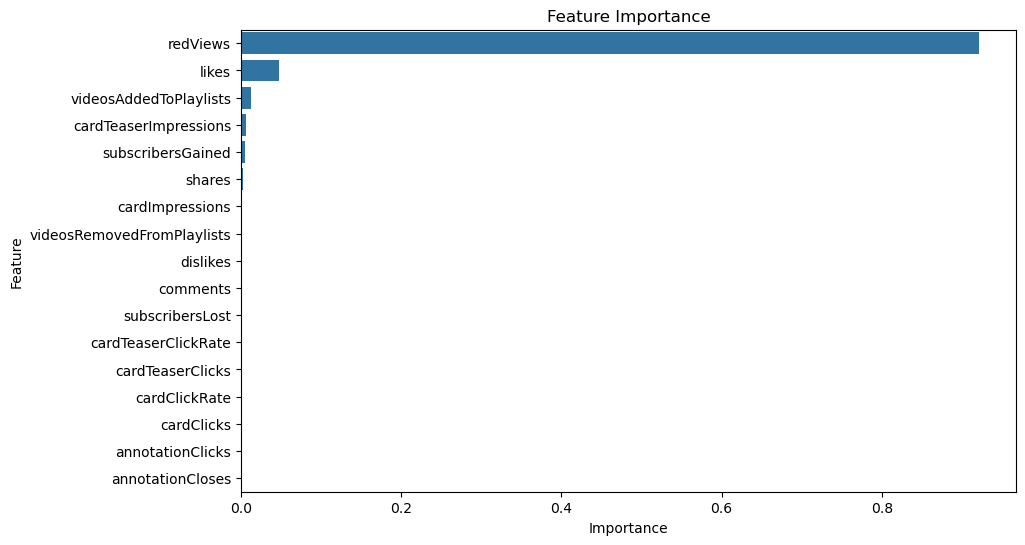

In [14]:
# Get feature importances
feature_importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

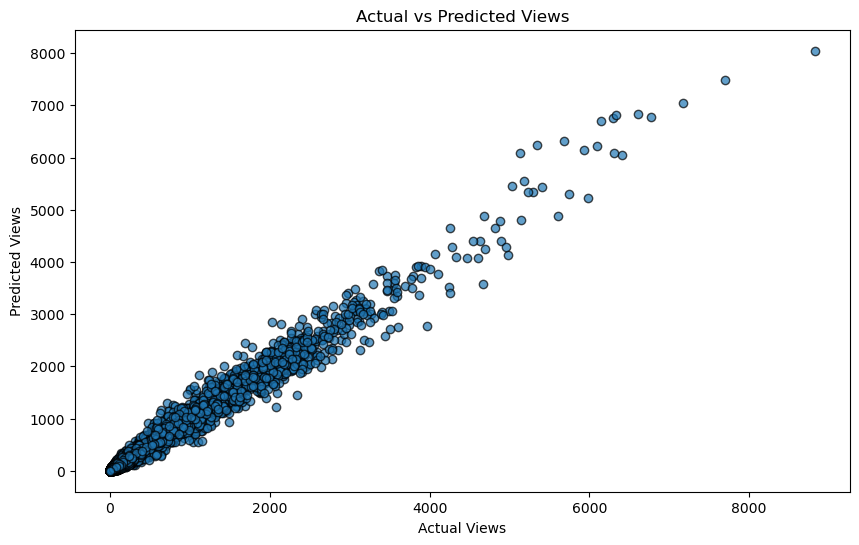

In [15]:
# Plot Actual vs Predicted Views
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.title("Actual vs Predicted Views")
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")
plt.show()

In [16]:
import joblib

# Save the trained model
joblib.dump(model, "youtube_views_model.pkl")

# Load the model later
loaded_model = joblib.load("youtube_views_model.pkl")

# Test loaded model with new data
new_data = [[500, 20, 100, 5, 10, 2, 15, 3, 1, 0.15, 0.10, 1000, 200, 50, 25, 10, 5]]  # Example input
new_prediction = loaded_model.predict(new_data)
print("Predicted Views for new data:", new_prediction)

Predicted Views for new data: [2801.35]


C:\Users\dipay\Downloads\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
